In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
# Load datasets correctly
red_wine = pd.read_csv("/content/winequality-red.csv", sep=';')
white_wine = pd.read_csv("/content/winequality-white.csv", sep=';')


In [5]:
print("Red wine shape:", red_wine.shape)
print("White wine shape:", white_wine.shape)

print("\nRed wine columns:\n", red_wine.columns)
print("\nWhite wine columns:\n", white_wine.columns)


Red wine shape: (1599, 12)
White wine shape: (4898, 12)

Red wine columns:
 Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

White wine columns:
 Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [6]:
red_wine.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:

white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
#print("Red wine")
#print(wine_red.isnull().sum())
#print("\nWhite wine")
#print(wine_white.isnull().sum())

In [9]:
red_wine.info()
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column        

In [10]:
print("\nDuplicate rows in RED:", red_wine.duplicated().sum())
print("Duplicate rows in WHITE:", white_wine.duplicated().sum())


Duplicate rows in RED: 240
Duplicate rows in WHITE: 937


In [11]:
red_wine.describe()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [12]:
white_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


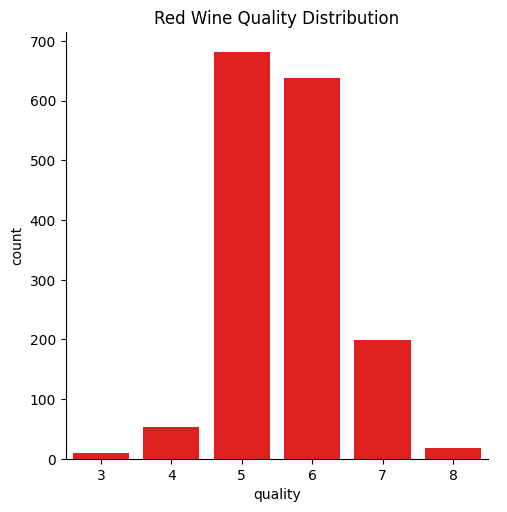

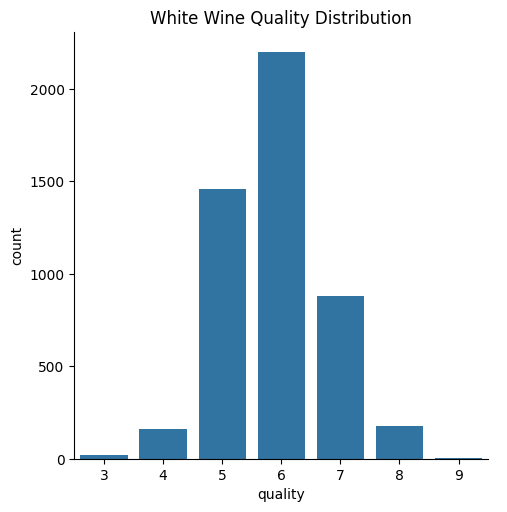

In [13]:
#class imbalance
sns.catplot(
    x='quality',
    data=red_wine,
    kind='count',
    color='red'
)
plt.title("Red Wine Quality Distribution")
plt.show()

sns.catplot(x='quality', data=white_wine, kind='count')
plt.title("White Wine Quality Distribution")
plt.show()


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

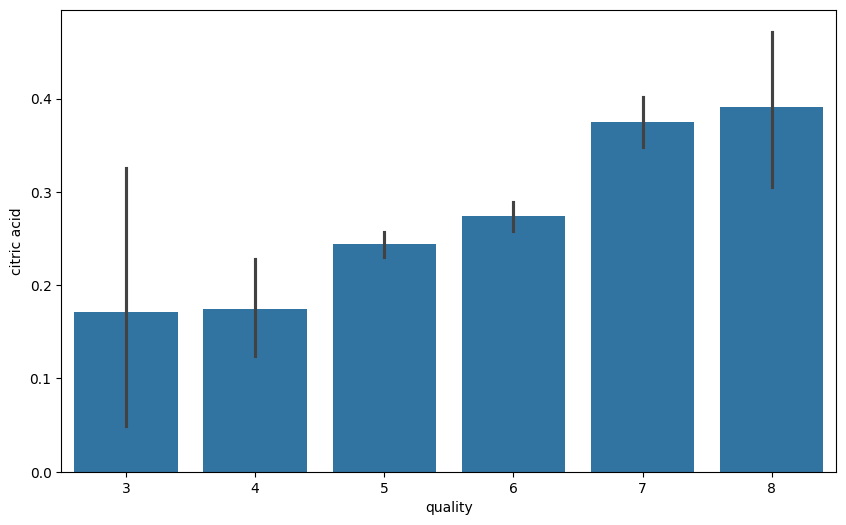

In [14]:
#citric acide vs quality
plot = plt.figure(figsize=(10, 6))
sns.barplot(x='quality', y='citric acid', data=red_wine)
plt

In [15]:
correlation = red_wine.corr()

<Axes: >

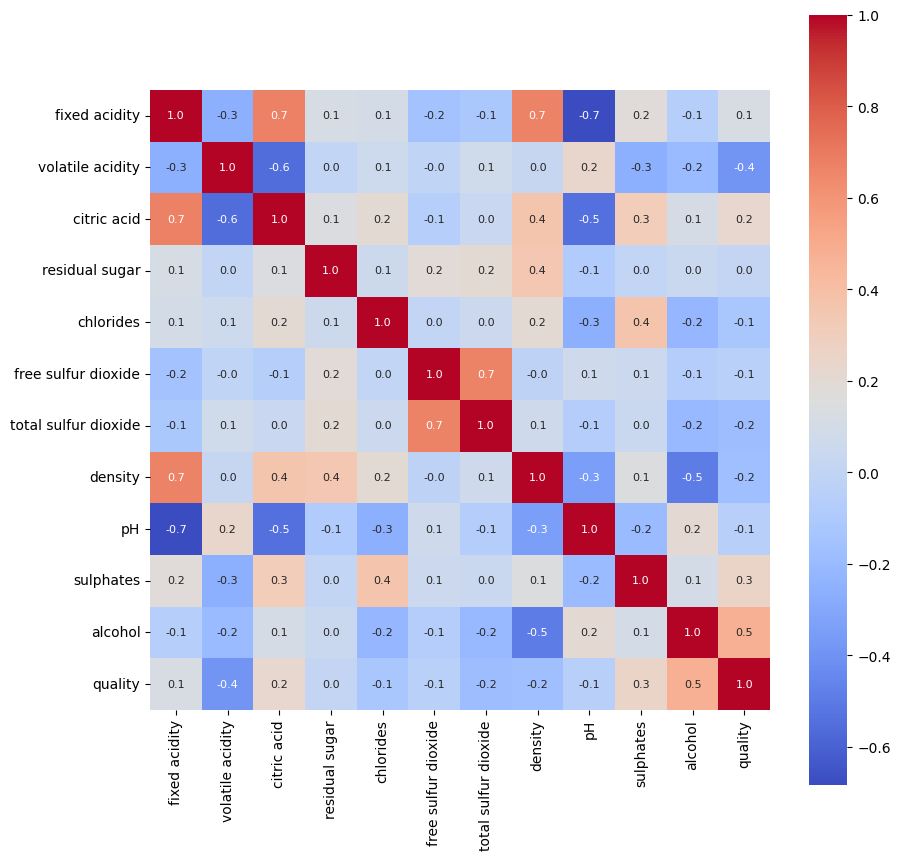

In [16]:


plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square =True, fmt = '.1f', annot =True ,annot_kws={'size' :8},  cmap='coolwarm')


In [17]:
#red_wine['quality_label'] = red_wine['quality'].apply(lambda x: 1 if x >= 7 else 0)
#white_wine['quality_label'] = white_wine['quality'].apply(lambda x: 1 if x >= 7 else 0)
# Multiclass target
y_red = red_wine['quality']
y_white = white_wine['quality']


In [19]:
#print(red_wine['quality_label'])

In [20]:

#print(red_wine['quality_label'].value_counts())
#print(white_wine['quality_label'].value_counts())




In [ ]:
#X_red = red_wine.drop(['quality', 'quality_label'], axis=1)
#y_red = red_wine['quality_label']


In [21]:
#print(X_red)

In [22]:
#train & 0test split
#multiclass
X_red = red_wine.drop('quality', axis=1)
X_white = white_wine.drop('quality', axis=1)
y_red = red_wine['quality']
y_white = white_wine['quality']
#X_white = white_wine.drop(['quality', 'quality_label'], axis=1)
#y_white = white_wine['quality_label']


In [23]:
'''Xr_train, Xr_test, yr_train, yr_test = train_test_split(
      X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
   X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)'''

from sklearn.model_selection import train_test_split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y_red,
    test_size=0.2,
    random_state=42,
    stratify=y_red
)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white, y_white,
    test_size=0.2,
    random_state=42,
    stratify=y_white
)




In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

Xr_train_res, yr_train_res = smote.fit_resample(Xr_train, yr_train)
Xw_train_res, yw_train_res = smote.fit_resample(Xw_train, yw_train)


In [ ]:
print(Xr_train.shape, yr_train.shape,Xr_test.shape, yr_test.shape)
print(Xw_train.shape, yw_train.shape,Xw_test.shape, yw_test.shape)

(1279, 11) (1279,) (320, 11) (320,)
(3918, 11) (3918,) (980, 11) (980,)


In [24]:
#Random forest
'''model_red = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_red.fit(Xr_train, yr_train)

'''


from sklearn.ensemble import RandomForestClassifier

model_red = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_white = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_red.fit(Xr_train, yr_train)
model_white.fit(Xw_train, yw_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
model_white = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_white.fit(Xw_train, yw_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
#Accuracy Score

yr_prediction = model_red.predict(Xr_test)

print("Red Wine Accuracy:", accuracy_score(yr_test, yr_prediction))
#print(classification_report(yr_test, yr_prediction))


Red Wine Accuracy: 0.940625


In [ ]:
yw_prediction = model_white.predict(Xw_test)

print("White Wine Accuracy:", accuracy_score(yw_test, yw_prediction))
#print(classification_report(yw_test, yw_prediction))


White Wine Accuracy: 0.8887755102040816


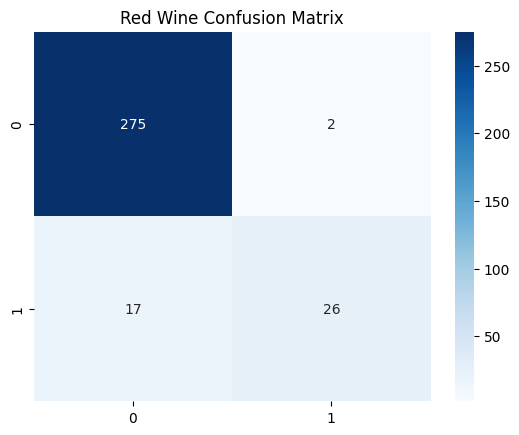

In [ ]:
sns.heatmap(confusion_matrix(yr_test, yr_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Red Wine Confusion Matrix")
plt.show()


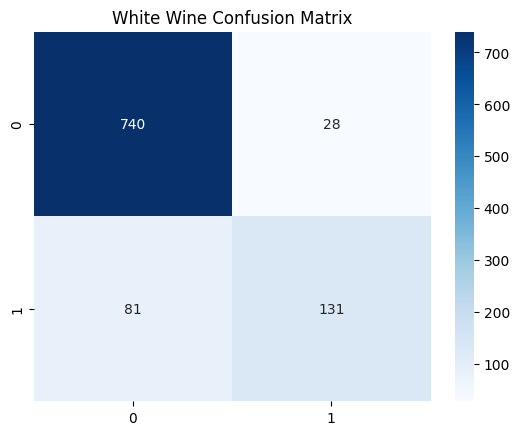

In [ ]:
sns.heatmap(confusion_matrix(yw_test, yw_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("White Wine Confusion Matrix")
plt.show()


In [ ]:
importances = model_red.feature_importances_
features = X_red.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp


,Feature,Importance
10,alcohol,0.170513
9,sulphates,0.113009
1,volatile acidity,0.102843
7,density,0.099223
2,citric acid,0.092148
6,total sulfur dioxide,0.080623
0,fixed acidity,0.075441
4,chlorides,0.073359
3,residual sugar,0.068973
8,pH,0.062538
